In [1]:
from IPython.display import Image, display
import pandas as pd

from drug_data import DATA, LABELS
from eunoia_versions import run

OLD, NEW = "0.5.0", "0.6.0"

for name, members in DATA.items():
    print(f"{name:14s} n={len(members)}")

Atorvastatin   n=51
Simvastatin    n=46
Sunitinib      n=39


In [2]:
from measure import true_region_counts

counts = true_region_counts(DATA, LABELS)
for region, n in sorted(counts.items(), key=lambda kv: -kv[1]):
    print(f"{n:4d}  {region}")

  35  Atorvastatin
  35  Sunitinib
  32  Simvastatin
  12  Atorvastatin&Simvastatin
   2  Atorvastatin&Sunitinib
   2  Atorvastatin&Simvastatin&Sunitinib
   0  Simvastatin&Sunitinib


eunoia 0.5.0


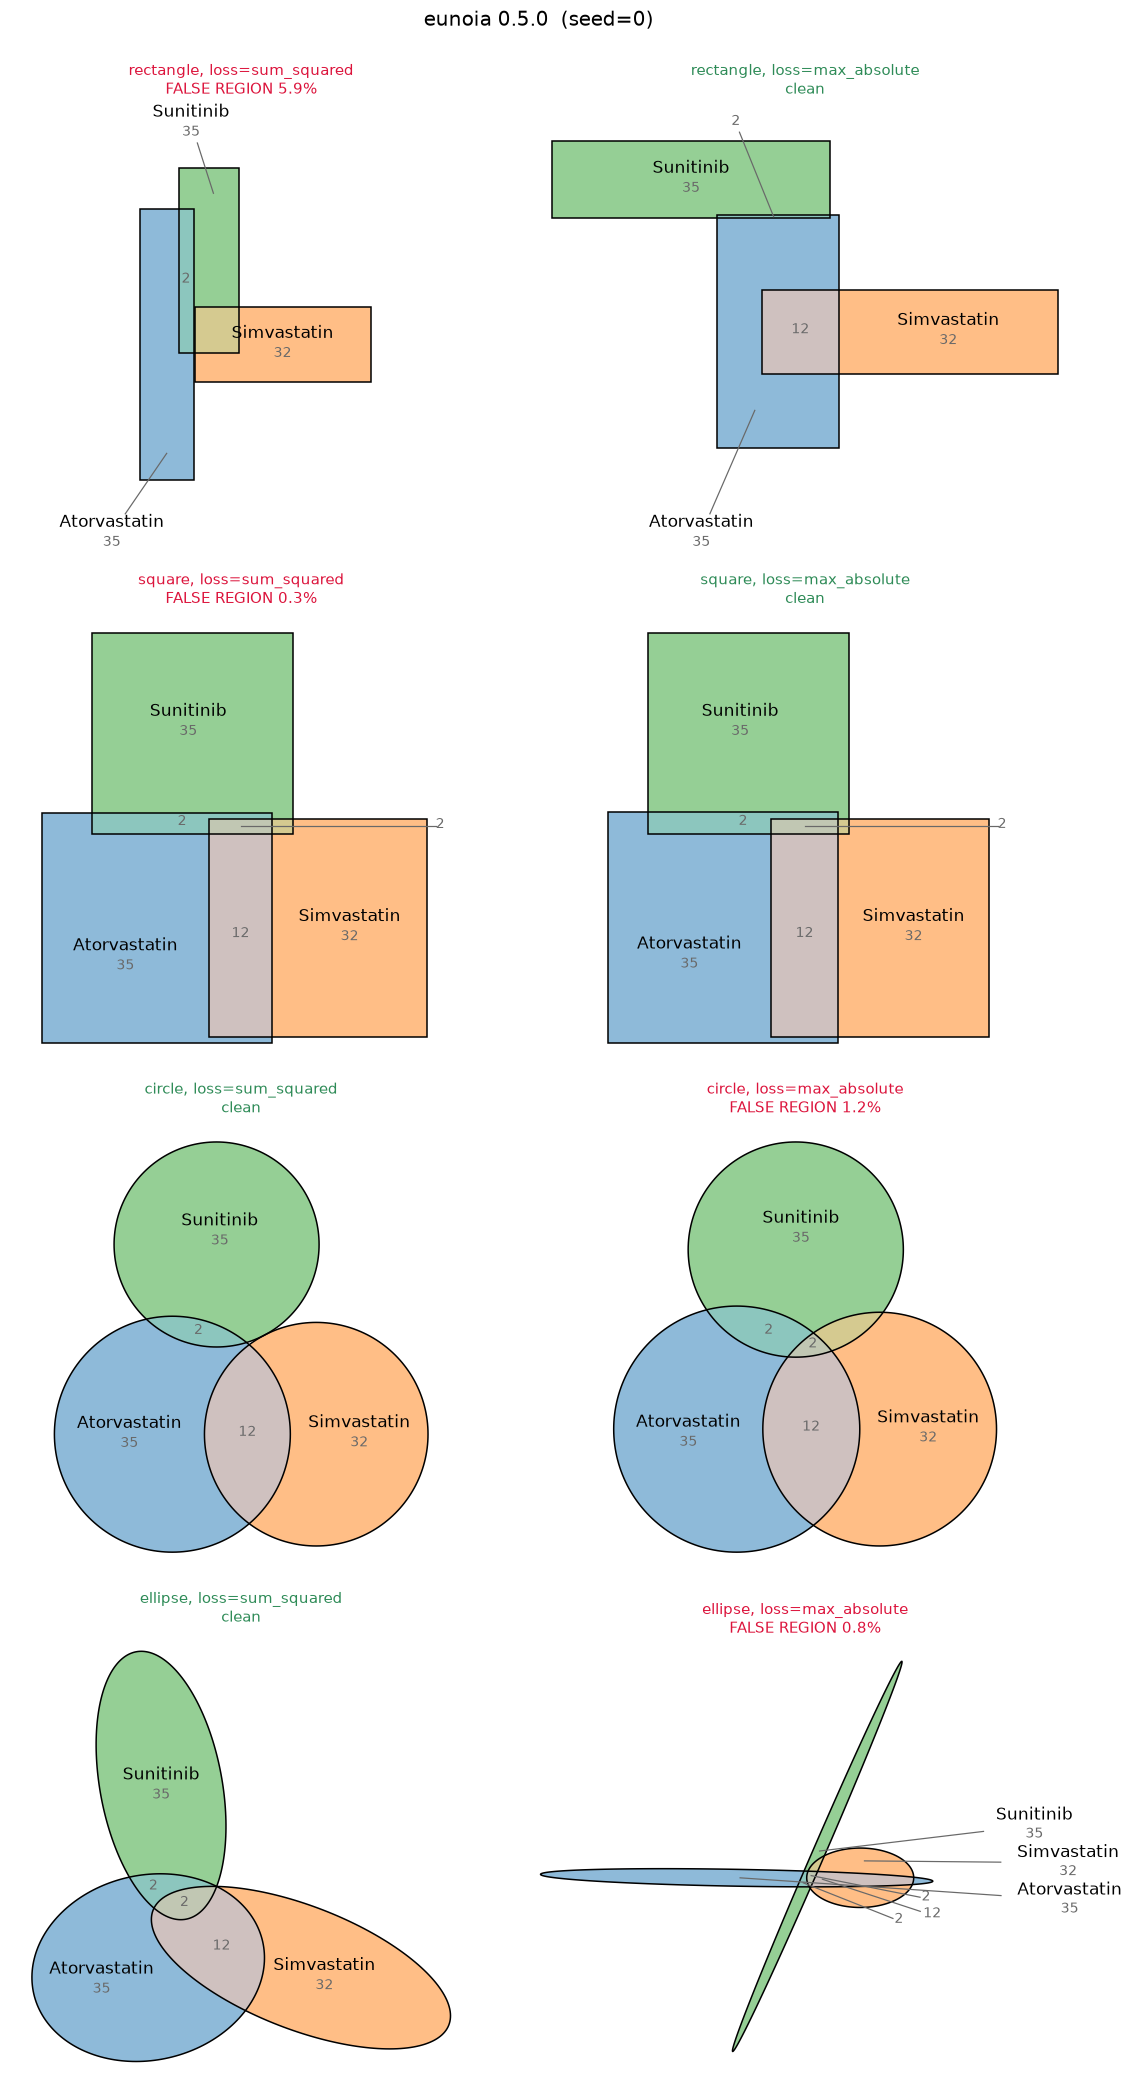

eunoia 0.6.0


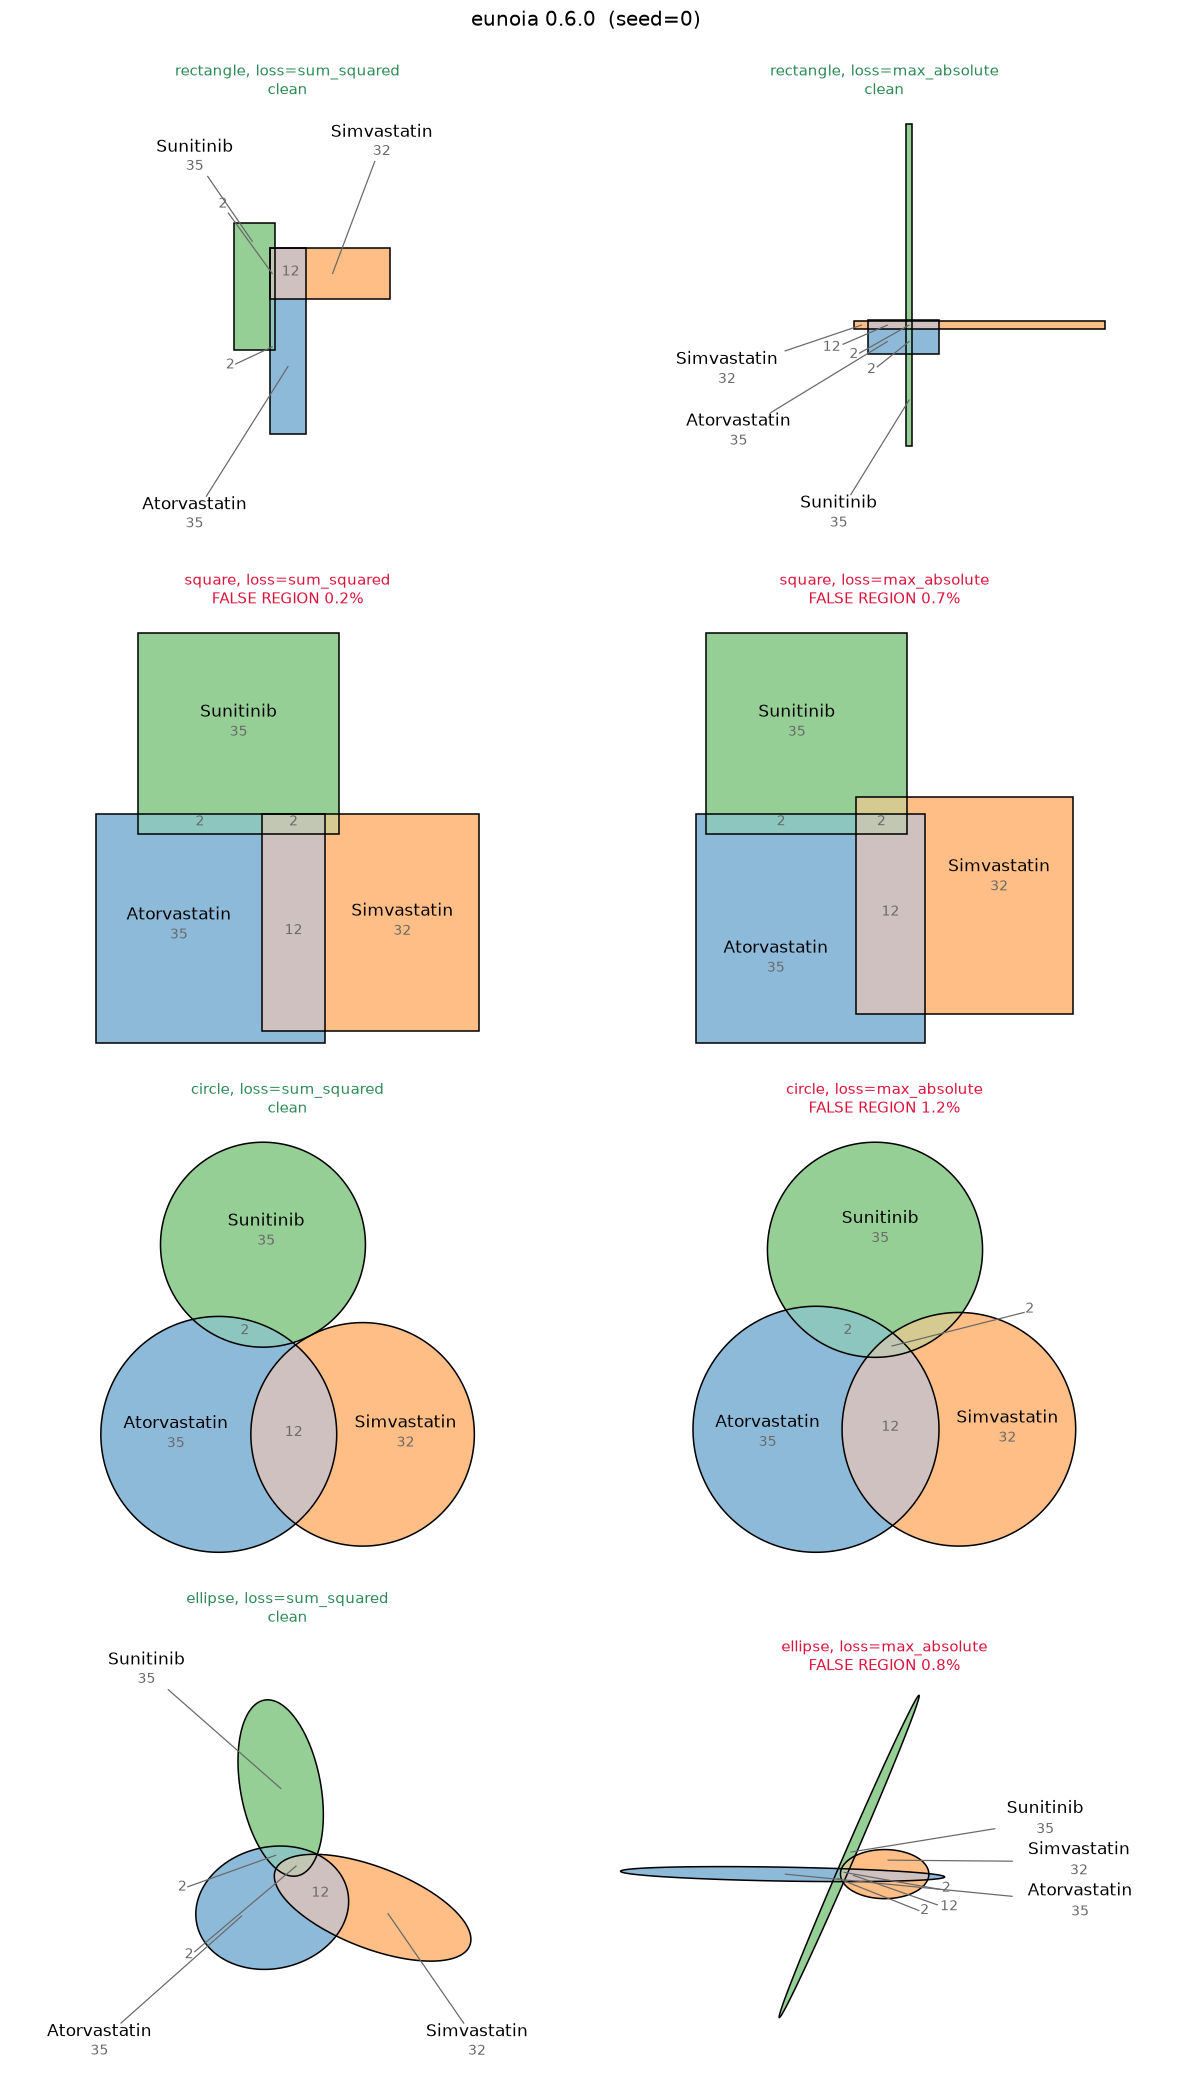

In [3]:
for version in (OLD, NEW):
    out = f"compare_{version.replace('.', '')}.png"
    run(version, f"import render; render.grid({out!r})")
    print(f"eunoia {version}")
    display(Image(out))

In [4]:
import json

res = {v: json.loads(run(v, "import render; render.sweep(20)"))["counts"] for v in (OLD, NEW)}
rows = [{"shape": k.split("|")[0], "loss": k.split("|")[1],
         f"{OLD}": f"{res[OLD][k]:>2}/20", f"{NEW}": f"{res[NEW][k]:>2}/20"} for k in res[OLD]]
pd.DataFrame(rows).set_index(["shape", "loss"])

0.5.0  0.6.0
shape     loss                      
rectangle sum_squared   16/20   0/20
          max_absolute  13/20  15/20
square    sum_squared   20/20   8/20
          max_absolute  15/20  20/20
circle    sum_squared    0/20   0/20
          max_absolute  20/20  20/20
ellipse   sum_squared    0/20   0/20
          max_absolute  18/20  18/20

## 6. UpSet view of the same data

No geometry to get wrong — a useful cross-check on the counts.

C:\Users\user\anaconda3\envs\viset\Lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


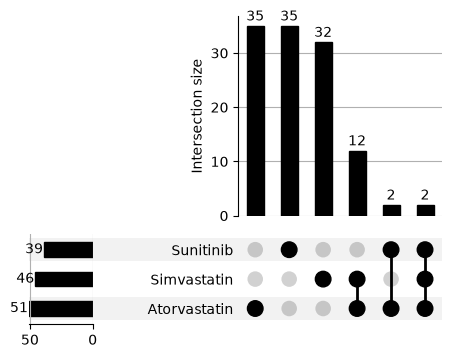

In [5]:
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_contents

UpSet(from_contents(DATA), sort_by='cardinality', show_counts=True).plot()
plt.show()